# Phase 2 - Analyse SQL
## Création de la base de données et requêtes business
Dataset : Credit Card Fraud Detection


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset
df = pd.read_csv("../creditcard.csv")

# Créer la base de données SQLite
conn = sqlite3.connect("../fraud.db")

# Importer le dataframe dans la base SQL
df.to_sql("transactions", conn, if_exists="replace", index=False)

print("✓ Base de données créée : fraud.db")
print("✓ Table 'transactions' importée avec succès")
print(f"✓ {len(df):,} lignes chargées")

✓ Base de données créée : fraud.db
✓ Table 'transactions' importée avec succès
✓ 284,807 lignes chargées


In [2]:
# REQUÊTE 1 : Vue globale fraude vs normal
query1 = """
SELECT 
    CASE WHEN Class = 0 THEN 'Normal' ELSE 'Fraude' END AS type_transaction,
    COUNT(*) AS nombre,
    ROUND(AVG(Amount), 2) AS montant_moyen,
    ROUND(MIN(Amount), 2) AS montant_min,
    ROUND(MAX(Amount), 2) AS montant_max,
    ROUND(SUM(Amount), 2) AS montant_total
FROM transactions
GROUP BY Class
"""
result1 = pd.read_sql_query(query1, conn)
print("=== VUE GLOBALE FRAUDE VS NORMAL ===")
print(result1.to_string(index=False))

=== VUE GLOBALE FRAUDE VS NORMAL ===
type_transaction  nombre  montant_moyen  montant_min  montant_max  montant_total
          Normal  284315          88.29          0.0     25691.16    25102462.04
          Fraude     492         122.21          0.0      2125.87       60127.97


In [3]:
# REQUÊTE 2 : Tranches de montants frauduleux
query2 = """
SELECT 
    CASE 
        WHEN Amount < 10 THEN '< 10€'
        WHEN Amount < 50 THEN '10€ - 50€'
        WHEN Amount < 100 THEN '50€ - 100€'
        WHEN Amount < 500 THEN '100€ - 500€'
        ELSE '> 500€'
    END AS tranche_montant,
    COUNT(*) AS nb_fraudes,
    ROUND(AVG(Amount), 2) AS montant_moyen
FROM transactions
WHERE Class = 1
GROUP BY tranche_montant
ORDER BY nb_fraudes DESC
"""
result2 = pd.read_sql_query(query2, conn)
print("=== TRANCHES DE MONTANTS FRAUDULEUX ===")
print(result2.to_string(index=False))

=== TRANCHES DE MONTANTS FRAUDULEUX ===
tranche_montant  nb_fraudes  montant_moyen
          < 10€         249           1.84
    100€ - 500€          95         230.67
     50€ - 100€          57          87.64
      10€ - 50€          56          27.95
         > 500€          35         891.28


In [4]:
# REQUÊTE 3 : Analyse temporelle - fraudes par période
query3 = """
SELECT 
    CASE 
        WHEN (Time % 86400) < 21600 THEN '00h-06h (Nuit)'
        WHEN (Time % 86400) < 43200 THEN '06h-12h (Matin)'
        WHEN (Time % 86400) < 64800 THEN '12h-18h (Après-midi)'
        ELSE '18h-24h (Soir)'
    END AS periode,
    COUNT(*) AS nb_fraudes,
    ROUND(AVG(Amount), 2) AS montant_moyen
FROM transactions
WHERE Class = 1
GROUP BY periode
ORDER BY nb_fraudes DESC
"""
result3 = pd.read_sql_query(query3, conn)
print("=== FRAUDES PAR PÉRIODE DE LA JOURNÉE ===")
print(result3.to_string(index=False))

=== FRAUDES PAR PÉRIODE DE LA JOURNÉE ===
             periode  nb_fraudes  montant_moyen
12h-18h (Après-midi)         134         144.44
      00h-06h (Nuit)         124          87.23
     06h-12h (Matin)         118         121.80
      18h-24h (Soir)         116         134.35


In [5]:
# REQUÊTE 4 : Impact financier des fraudes
query4 = """
SELECT 
    ROUND(SUM(CASE WHEN Class = 1 THEN Amount ELSE 0 END), 2) AS pertes_fraude,
    ROUND(SUM(CASE WHEN Class = 0 THEN Amount ELSE 0 END), 2) AS volume_normal,
    ROUND(SUM(Amount), 2) AS volume_total,
    ROUND(SUM(CASE WHEN Class = 1 THEN Amount ELSE 0 END) * 100.0 / SUM(Amount), 4) AS pct_pertes
FROM transactions
"""
result4 = pd.read_sql_query(query4, conn)
print("=== IMPACT FINANCIER DES FRAUDES ===")
print(f"Volume total transactions : {result4['volume_total'][0]:,.2f}€")
print(f"Pertes dues aux fraudes   : {result4['pertes_fraude'][0]:,.2f}€")
print(f"Volume transactions saines: {result4['volume_normal'][0]:,.2f}€")
print(f"% des pertes / volume     : {result4['pct_pertes'][0]:.4f}%")

=== IMPACT FINANCIER DES FRAUDES ===
Volume total transactions : 25,162,590.01€
Pertes dues aux fraudes   : 60,127.97€
Volume transactions saines: 25,102,462.04€
% des pertes / volume     : 0.2390%


In [6]:
# REQUÊTE 5 : Top 10 transactions frauduleuses les plus coûteuses
query5 = """
SELECT 
    ROUND(Amount, 2) AS montant,
    ROUND(Time / 3600, 1) AS heure,
    V1, V2, V3
FROM transactions
WHERE Class = 1
ORDER BY Amount DESC
LIMIT 10
"""
result5 = pd.read_sql_query(query5, conn)
print("=== TOP 10 FRAUDES LES PLUS COÛTEUSES ===")
print(result5.to_string(index=False))

=== TOP 10 FRAUDES LES PLUS COÛTEUSES ===
 montant  heure         V1        V2         V3
 2125.87   34.1  -2.003460 -7.159042  -4.050976
 1809.68    2.5  -3.499108  0.258555  -4.489558
 1504.93   42.9  -1.600211 -3.488130  -6.459303
 1402.16   17.4  -5.344665 -0.285760  -3.835616
 1389.56   16.4  -2.326922 -3.348439  -3.513408
 1354.25   18.2  -2.923827  1.524837  -3.018758
 1335.00   37.0  -1.212682 -2.484824  -6.397186
 1218.89    5.0 -12.224021  3.854150 -12.466766
 1096.99   42.9  -0.082983 -3.935919  -2.616709
  996.27   41.0  -1.611877 -0.408410  -3.829762


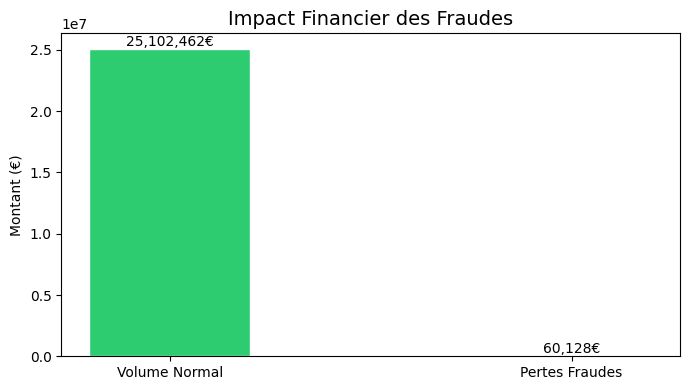

✓ Phase 2 - Analyse SQL terminée !


In [7]:
# Visualisation impact financier
categories = ['Volume Normal', 'Pertes Fraudes']
valeurs = [25102462.04, 60127.97]
couleurs = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(7, 4))
bars = plt.bar(categories, valeurs, color=couleurs, edgecolor='white', width=0.4)
plt.title('Impact Financier des Fraudes', fontsize=14)
plt.ylabel('Montant (€)')
for bar, val in zip(bars, valeurs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200000,
             f'{val:,.0f}€', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("../reports/impact_financier.png")
plt.show()
print("✓ Phase 2 - Analyse SQL terminée !")